# plot styling

yabplot provides several styling presets and customization options to make your figures publication-ready.

in this tutorial, we will explore:
1. lighting styles.
2. customizing the background context brain.
3. handling missing data (`nan_color`, `nan_alpha`).
4. tract-specific visualizations.

In [1]:
import yabplot as yab
import numpy as np

## 1. lighting styles
different styles can highlight shape (sculpted) or data values (flat/matte). available styles include: `'default'`, `'matte'`, `'glossy'`, `'sculpted'`, `'flat'`.

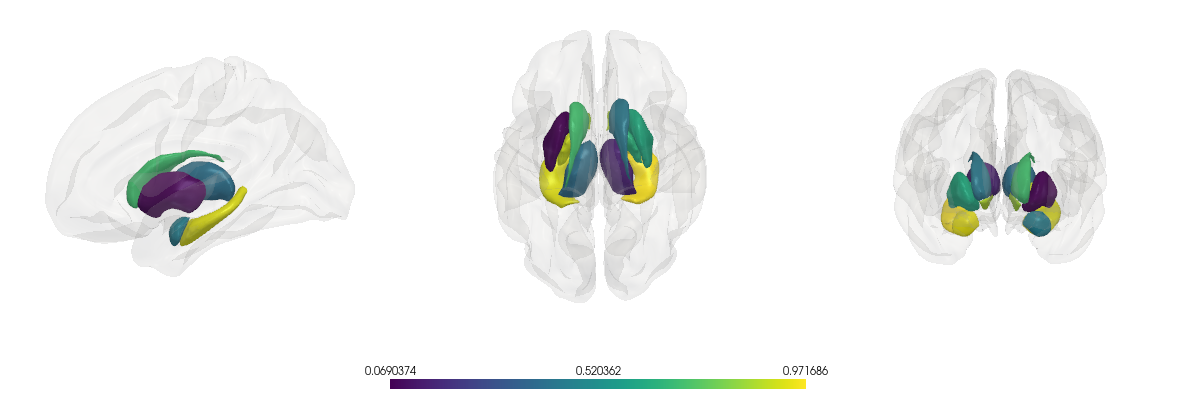

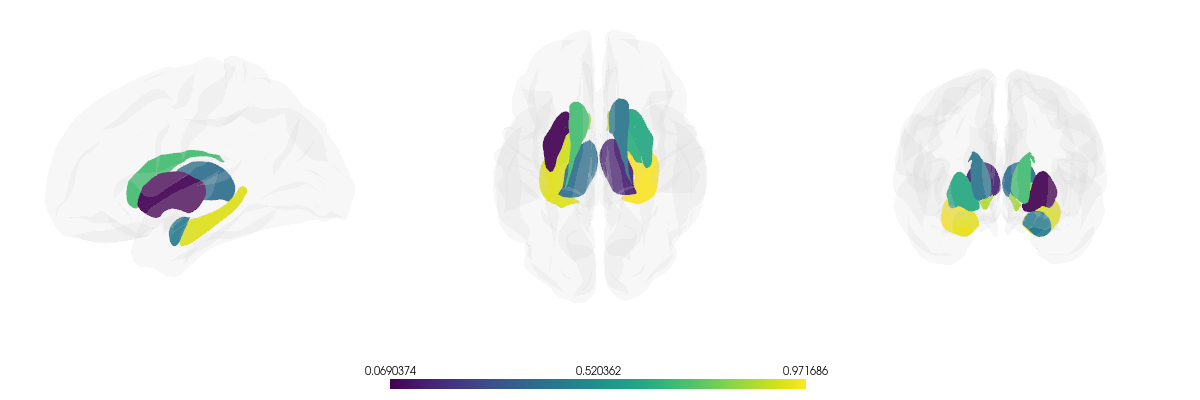

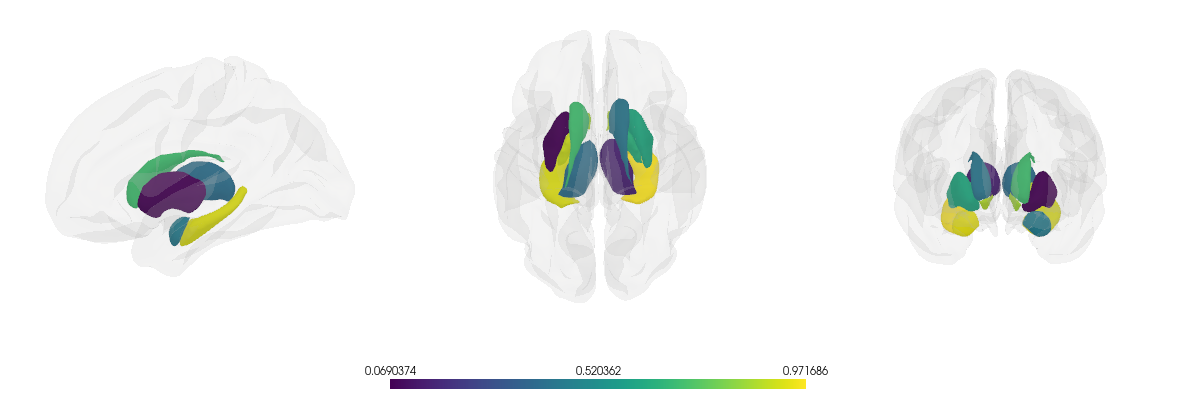

In [2]:
# generate random data for demonstration
regions = yab.get_atlas_regions('aseg', 'subcortical')
data = np.random.rand(len(regions))

# compare 'flat' vs 'glossy' vs 'matte' styles
# glossy enhances the 3d curvature giving it a shiny look
yab.plot_subcortical(
    data=data,
    cmap='viridis',
    atlas='aseg',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    style='glossy'
)

# flat is great for seeing exact data colors without shadows
yab.plot_subcortical(
    data=data,
    cmap='viridis',
    atlas='aseg',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    style='flat'
)

# matte is a balance between both
yab.plot_subcortical(
    data=data,
    cmap='viridis',
    atlas='aseg',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    style='matte'
)

## 2. context brain (bmesh)
for subcortical and tract plots, a context brain mesh is rendered to show anatomical location. you can change its style or hide it.

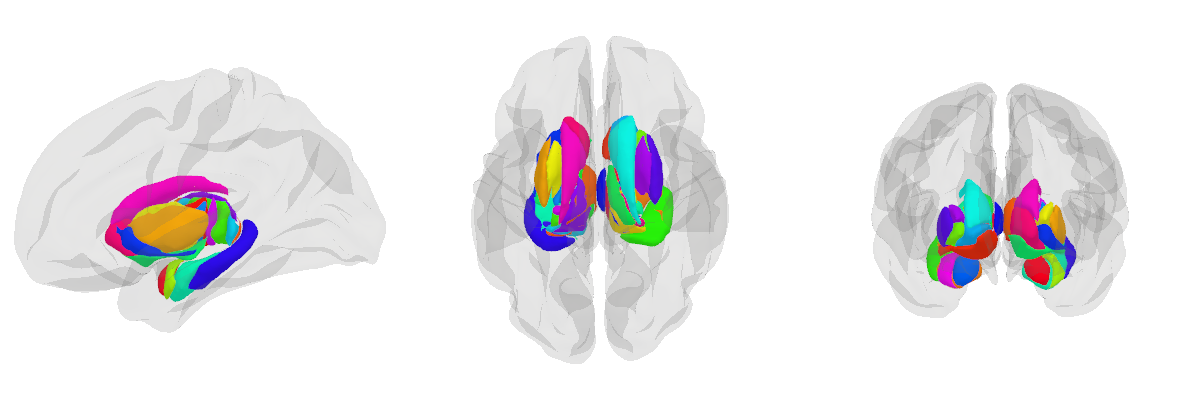

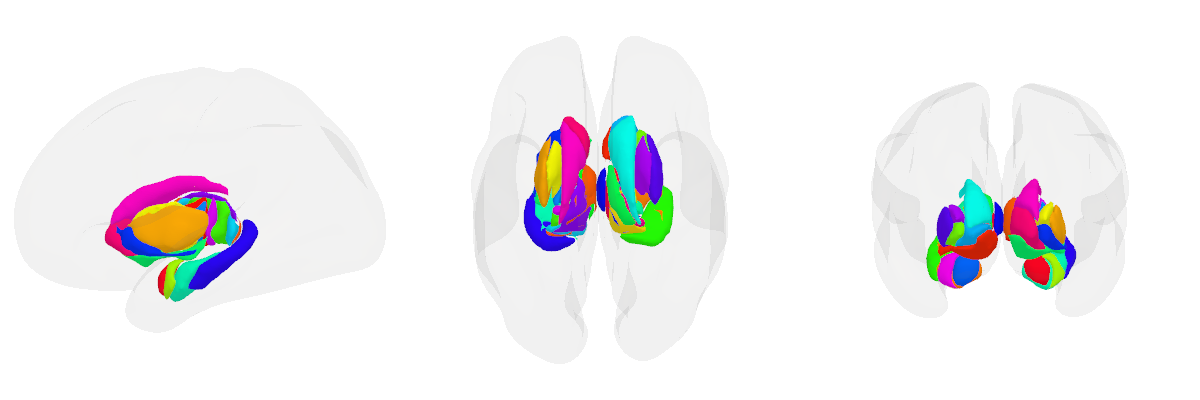

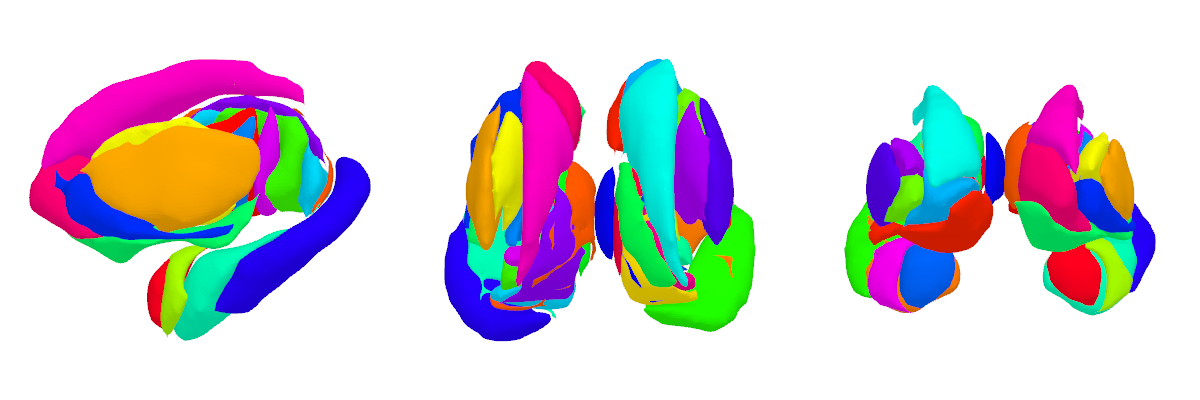

In [3]:
# styling the context brain
yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    bmesh='midthickness',       # standard surface
    bmesh_alpha=0.1,            # very transparent
    bmesh_color='gray',         # dark background mesh
    style='default',
    display_type='static'
)
yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    bmesh='inflated',         # inflated surface
    bmesh_alpha=0.05,         # even more transparent
    bmesh_color='gray',       # dark background mesh
    style='default',
    display_type='static'
)

# hiding the context brain
yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    figsize=(1200, 400),
    bmesh=None,               # no context surface
    style='default',
    display_type='static'
)

## 3. handling missing data (nan)
when plotting dictionaries or incomplete arrays, you can control how missing regions appear using `nan_color` and `nan_alpha`.

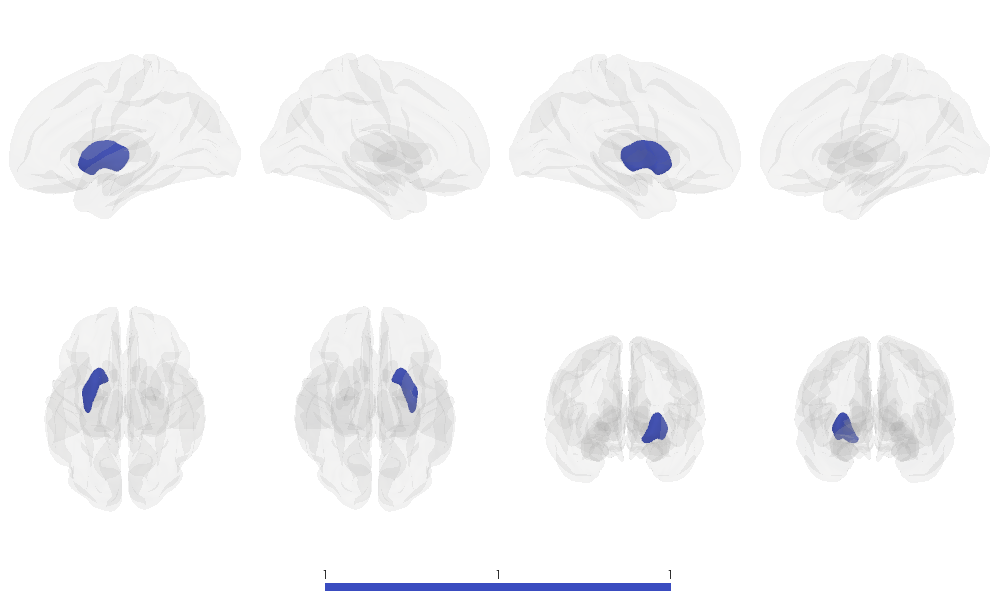

In [4]:
# define data for only one region
sparse_data = {'Left-Putamen': 1.0}

yab.plot_subcortical(
    data=sparse_data,
    atlas='aseg',
    # make missing regions white and fully opaque (solid)
    nan_color='gray',
    nan_alpha=0.05,
    style='matte',
    display_type='static'
)

## 4. tract customization
for white matter tracts, you can pass specific parameters to pyvista to change the rendering of lines/tubes via `tract_kwargs`.

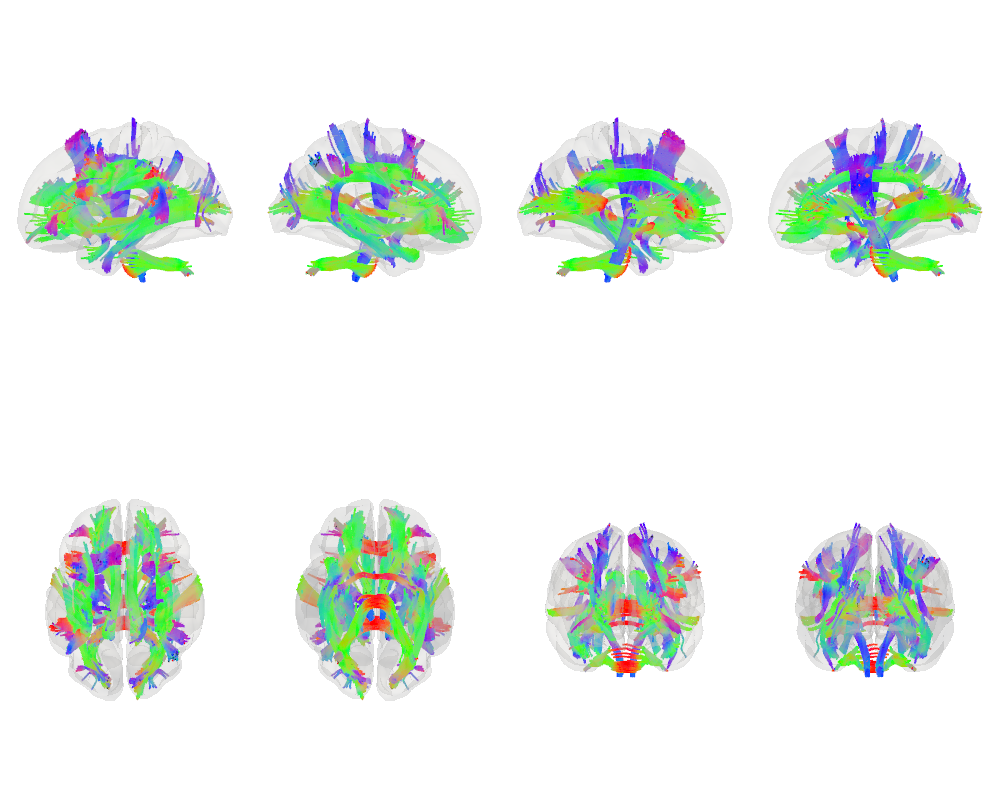

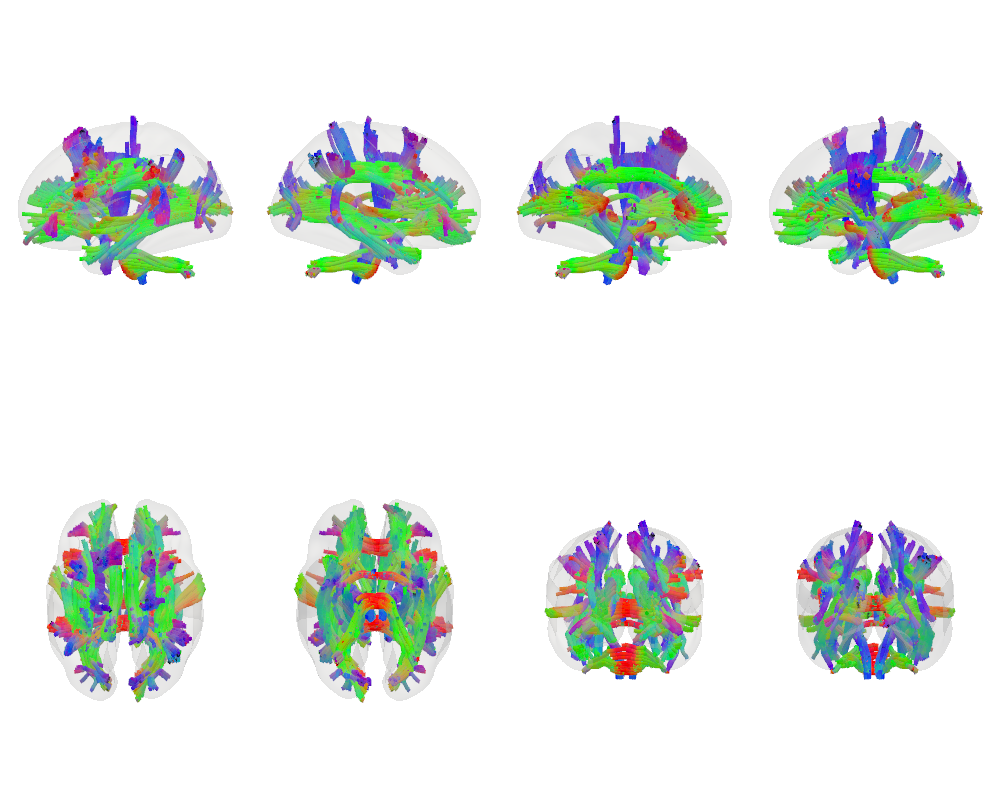

In [5]:
# render tracts as thin lines instead of 3d tubes (faster, different look)
yab.plot_tracts(
    atlas='xtract_tiny',
    orientation_coloring=True,
    bmesh='pial',
    tract_kwargs={
        'render_lines_as_tubes': False,  # simple lines
        'line_width': 2.0                # slightly thicker lines
    },
    display_type='static'
)

# render as thick tubes
yab.plot_tracts(
    atlas='xtract_tiny',
    orientation_coloring=True,
    bmesh='inflated',
    tract_kwargs={
        'render_lines_as_tubes': True,
        'line_width': 4.0  # very thick tubes
    },
    display_type='static'
)